# Chapter 5: Advanced Parametric vs The ML Floor (Fast Multi-Ticker Showdown)

This notebook implements the hyper-optimized pipeline to compare the `VIX-Scaled Student-T` baseline against the `WideAndDeep` Neural Network over a rigorous expanding window walk-forward backtest.

We measure:
1. **CRPS (Sharpness)**: Lower is better.
2. **Block K-S Failure Rate (Calibration)**: What percentage of 60-day windows fail the K-S test? (Lower is better).

In [61]:
import warnings
warnings.filterwarnings('ignore')

import sys

from datetime import date
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t

from density_forecasting.evaluation.metrics import block_ks_test
from density_forecasting.evaluation.metrics import evaluate_forecasts
from density_forecasting.models.neural_networks import generate_montecarlo

# Import our optimized pipeline functions
from density_forecasting.evaluation.fast_pipeline import (
    read_data_features,
    extract_array,
    extract_df_nn,
    run_baseline,
    backtesting_baseline,
    initializate_nn_model,
    run_neural_networks,
    backtesting_neural_networks
)


## 1. Configuration & Multi-Ticker Loop

In [62]:
# tickers = ['ARKK', 'USO', 'USDCLP=X', 'BTC-USD', 'SQM-B.SN']
# tickers = ['USO', 'BTC-USD']
tickers = ["SPY", "TSLA", "DBK.DE"]
# tickers = ["SPY"]


# tickers = ["SPY", "TSLA", "DBK.DE", "SQM-B.SN", "CENCOSUD.SN"]

# tickers = ['SQM-B.SN']
start_date = date(2010, 12, 31)
end_date = date(2025, 12, 31)

columns_linear = ['ret_1_mean', 'ret_1', 'ret_2','ret_3', 'ret_1_std', 'ret_1_kurt', 'ret_1_skew', 'ret_1_mean_st', 'ret_1_std_st', 'vix_ratio', 'VIX']

# columns_deep = ['vix_ratio', 'VIX']
columns_linear = ['Feat_Realized_Vol_20', 'returns_m1', 'Feat_Momentum_20', 'returns_m1_std_st', 'returns_m1_kurt']
columns_deep = ['vix_ratio']

# columns_deep = ['vix_ratio', 'Feat_Volume_Shock', 'Feat_RSI_14']

# columns_deep = []

test_window = 22 * 1
min_train_data = 3000
# porcentage_train = 0.75

initial_epochs = 3000
model_class = 'WideAndDeep'
# model_class = 'Linear'

lr = 0.015

table_results = []


In [63]:
# df_features.columns
# drop_columns = ["returns", 'volume', 'Vol_50_MA', 'VIX', 'returns_m1_kurt', 'returns_m1_skew', 'returns_m1_nu']

In [64]:
# df_features.columns


STARTING FAST SHOWDOWN FOR SPY
Fetching SPY data...
Fetching VIX data...
Expanding Window Walk-Forward (Start Train Size: 3000)...
n_train: 3000, 82.44
Last epoch: 688, Loss: 4.2352
n_train: 3022, 83.04
Last epoch: 30, Loss: 4.2928
n_train: 3044, 83.65
Last epoch: 15, Loss: 4.3653
n_train: 3066, 84.25
Last epoch: 15, Loss: 4.4510
n_train: 3088, 84.86
Last epoch: 43, Loss: 4.5345
n_train: 3110, 85.46
Last epoch: 15, Loss: 4.6057
n_train: 3132, 86.07
Last epoch: 15, Loss: 4.6356
n_train: 3154, 86.67
Last epoch: 15, Loss: 4.7162
n_train: 3176, 87.28
Last epoch: 15, Loss: 4.7961
n_train: 3198, 87.88
Last epoch: 15, Loss: 5.0114
n_train: 3220, 88.49
Last epoch: 15, Loss: 5.1640
n_train: 3242, 89.09
Last epoch: 15, Loss: 5.2635
n_train: 3264, 89.69
Last epoch: 28, Loss: 5.4422
n_train: 3286, 90.30
Last epoch: 15, Loss: 5.5019
n_train: 3308, 90.90
Last epoch: 15, Loss: 5.4726
n_train: 3330, 91.51
Last epoch: 15, Loss: 5.4405
n_train: 3352, 92.11
Last epoch: 15, Loss: 5.4097
n_train: 3374, 92

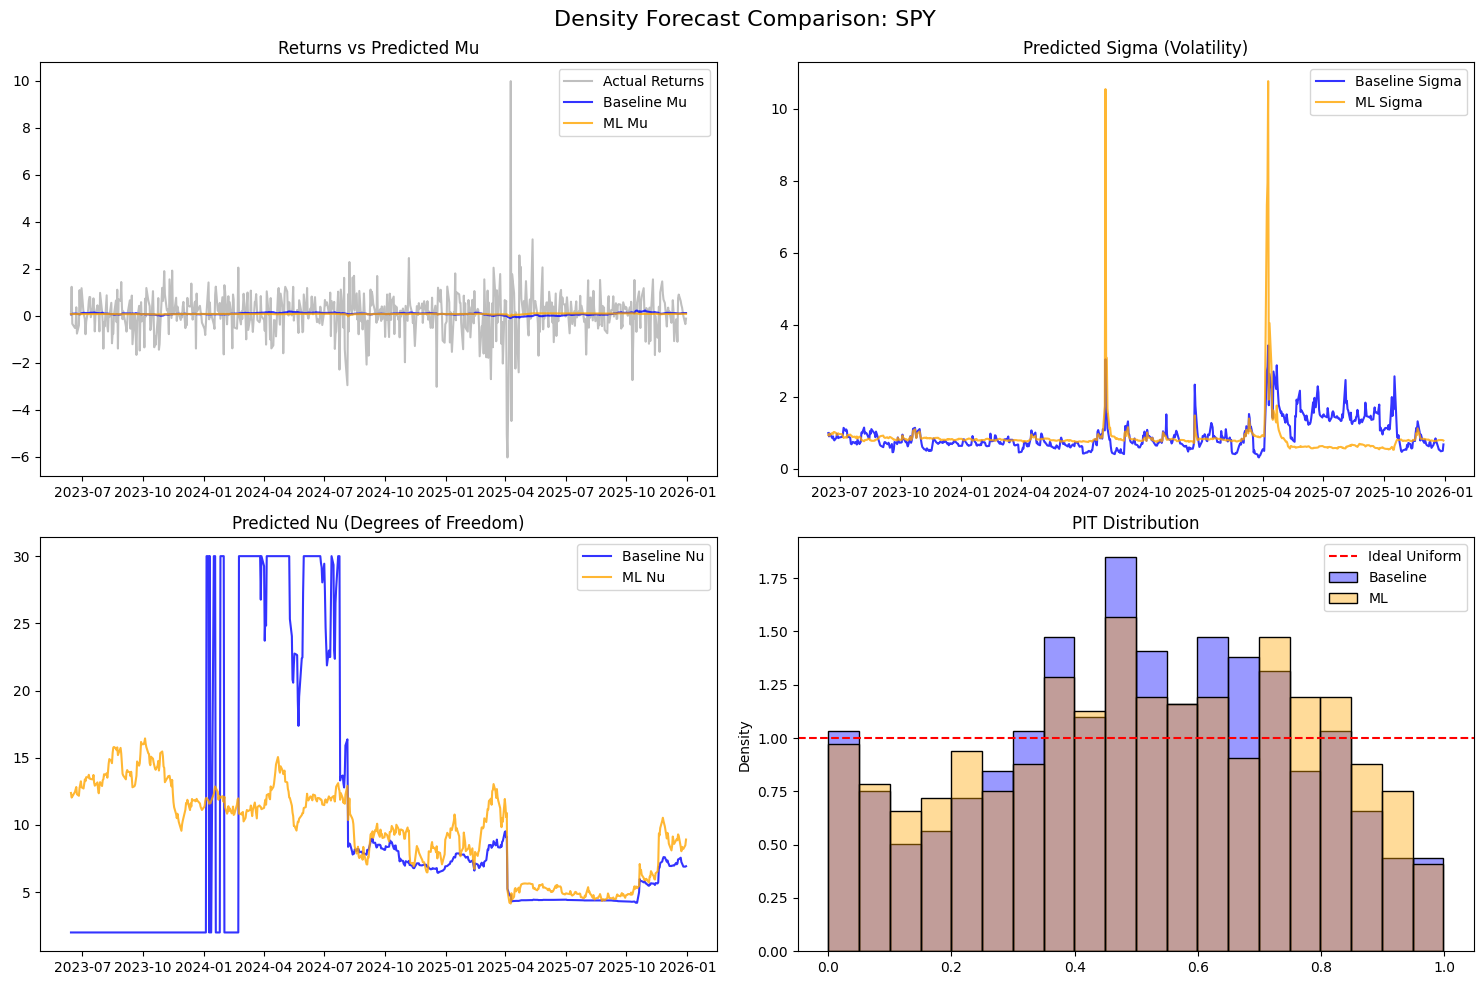


STARTING FAST SHOWDOWN FOR TSLA
Fetching TSLA data...
Fetching VIX data...
Expanding Window Walk-Forward (Start Train Size: 3000)...
n_train: 3000, 82.44
Last epoch: 2348, Loss: 3.7436
n_train: 3022, 83.04
Last epoch: 30, Loss: 3.7325
n_train: 3044, 83.65
Last epoch: 15, Loss: 3.7273
n_train: 3066, 84.25
Last epoch: 15, Loss: 3.7228
n_train: 3088, 84.86
Last epoch: 15, Loss: 3.7124
n_train: 3110, 85.46
Last epoch: 15, Loss: 3.7053
n_train: 3132, 86.07
Last epoch: 15, Loss: 3.6961
n_train: 3154, 86.67


KeyboardInterrupt: 

In [65]:
for ticker in tickers:
    print(f"\n{'='*50}")
    print(f"STARTING FAST SHOWDOWN FOR {ticker}")
    print(f"{'='*50}")
    
    # Setup Data
    df_features = read_data_features(ticker, start_date, end_date, window_size_long=22*6)

    # columns_linear = list(df_features.columns)
    # for col in drop_columns:
    #     columns_linear.remove(col)
    #     # columns_linear.remove('volume')
    #     # columns_linear.remove('Vol_50_MA')
    #     # columns_linear.remove('VIX')
    # # columns_linear.remove('vix_ratio')
    # # columns_linear.remove('Feat_Volume_Shock')

    
    # print(ticker)
    # print(df_features.head())
    dates_test = []
    pred_mu_result = {'baseline': [], 'neural-network': []}
    pred_sigma_result = {'baseline': [], 'neural-network': []}
    pred_nu_result = {'baseline': [], 'neural-network': []}
    pit_values_result = {'baseline': [], 'neural-network': []}
    
    n_train = min_train_data
    # n_train = int(porcentage_train * len(df_features))
    current_epochs = initial_epochs
    cold_start = True
    last_optimal_beta = 0.5
    
    # Initialize NN once per ticker
    train_step, model = initializate_nn_model(columns_linear, model_class, lr, columns_deep=columns_deep)
    
    print(f"Expanding Window Walk-Forward (Start Train Size: {n_train})...")
    
    while n_train < len(df_features):
        print(f'n_train: {n_train}, {(100 * n_train / len(df_features)):.2f}')
        df_features_train = df_features.iloc[:n_train]
        df_X_linear_train, df_X_deep_train, df_y_train = extract_df_nn(df_features_train, columns_linear, columns_deep)
        # 1. FIT: Calculate mean and std ONLY on the training data
        train_linear_mean = df_X_linear_train.mean()
        train_linear_std = df_X_linear_train.std()
        
        # 2. TRANSFORM TRAIN: Apply the scaler to the training data
        df_X_linear_train = (df_X_linear_train - train_linear_mean) / train_linear_std

        if len(columns_deep) > 0:
            train_deep_mean = df_X_deep_train.mean()
            train_deep_std = df_X_deep_train.std()
            df_X_deep_train = (df_X_deep_train - train_deep_mean) / train_deep_std
        
        # print(df_X_linear_train.head())
        # print(len(df_X_linear_train))
        # train_linear_mean, train_deep_mean = df_X_linear_train.mean(), df_X_deep_train.mean()
        # train_linear_std, train_deep_std = df_X_linear_train.std(), df_X_deep_train.std()

        # 3. TRANSFORM TEST: Apply the EXACT SAME Train scaler to the test data
        # test_df[features_to_normalize] = (test_df[features_to_normalize] - train_mean) / train_std

        # train_std = train_df[features_to_normalize].std()

        # train_std = train_df[features_to_normalize].std()

        df_features_test = df_features.iloc[n_train:n_train + test_window]
        df_X_linear_test, df_X_deep_test, df_y_test = extract_df_nn(df_features_test, columns_linear, columns_deep)
        df_X_linear_test = (df_X_linear_test - train_linear_mean) / train_linear_std
        
        if len(columns_deep) > 0:
            df_X_deep_test = (df_X_deep_test - train_deep_mean) / train_deep_std
        

        # We need this to check if there are any days to test
        if len(df_features_test) == 0:
            break

        dates_test.append(df_features_test.index)

        # Baseline
        data_train = extract_array(df_features_train, df_y_train)
        optimal_beta = run_baseline(data_train, last_optimal_beta, cold_start)
        last_optimal_beta = optimal_beta
        
        baseline_prior = backtesting_baseline(data_train, optimal_beta)
        prior_data = {'mu': baseline_prior['mu'], 'sigma': baseline_prior['sigma'], 'nu': baseline_prior['nu']}
        data_test = extract_array(df_features_test, df_y_test)
        baseline_results = backtesting_baseline(data_test, optimal_beta)

        # data_prior = {}
        # for key, values in data_train.items():
        #     data_prior[key] = [data_train[key][-1]]
        # baseline_prior = backtesting_baseline(data_prior, optimal_beta)
        # prior_data = {'mu': np.mean(baseline_prior['mu']), 'sigma': np.mean(baseline_prior['sigma']), 'nu': np.mean(baseline_prior['nu'])}

        # data_test = extract_array(df_features_test, df_y_test)
        # baseline_results = backtesting_baseline(data_test, optimal_beta)

        pred_mu_result['baseline'].append(baseline_results['mu'])
        pred_sigma_result['baseline'].append(baseline_results['sigma'])
        pred_nu_result['baseline'].append(baseline_results['nu'])
        pit_values_result['baseline'].append(baseline_results['pit_values'])

        # Neural Network
        # prior_data = {'mu': np.mean(baseline_results['mu']), 'sigma': np.mean(baseline_results['sigma']), 'nu': baseline_results['nu']}
        # run_neural_networks(df_X_linear_train, df_X_deep_train, df_y_train, current_epochs, train_step, prior_data, verbose=False)
        run_neural_networks(df_X_linear_train, df_X_deep_train, df_y_train, current_epochs, train_step, prior_data, verbose=False)
        
        if cold_start:
            current_epochs = 1000
            # current_epochs = current_epochs // 3
            cold_start = False

        neural_networks_results = backtesting_neural_networks(
            tf.convert_to_tensor(df_X_linear_test.to_numpy(), dtype=tf.float32), 
            tf.convert_to_tensor(df_X_deep_test.to_numpy(), dtype=tf.float32) if df_X_deep_test is not None else None, 
            tf.convert_to_tensor(df_y_test.to_numpy(), dtype=tf.float32), 
            model
        )

        pred_mu_result['neural-network'].append(neural_networks_results['mu'])
        pred_sigma_result['neural-network'].append(neural_networks_results['sigma'])
        pred_nu_result['neural-network'].append(neural_networks_results['nu'])
        pit_values_result['neural-network'].append(neural_networks_results['pit_values'])

        n_train += test_window

    # Combine Results for this Ticker
    dates_test_total = pd.Index(np.concatenate(dates_test))
    actual_returns = df_features['returns'].loc[dates_test_total]
    
    # Helper to compute metrics
    def calculate_metrics(model_name):
        mu_total = np.concatenate(pred_mu_result[model_name])
        sigma_total = np.concatenate(pred_sigma_result[model_name])
        nu_total = np.concatenate(pred_nu_result[model_name])
        pit_total = np.concatenate(pit_values_result[model_name])
        
        # Monte carlo for CRPS
        ensembles = generate_montecarlo(mu_total, sigma_total, nu_total, n_samples=1500)
        df_eval = evaluate_forecasts(actual_returns, ensembles)
        
        crps = df_eval['CRPS'].mean()
        
        # Block KS
        df_pit_total = pd.DataFrame(pit_total, index=df_eval.index)
        df_ks = block_ks_test(df_pit_total, block_size=22*6, alpha=0.05)
        ks_fail = (df_ks['Status'] == '❌ FAILED').mean() if len(df_ks) > 0 else 1.0
        
        return crps, ks_fail
        
    crps_base, ks_base = calculate_metrics('baseline')
    crps_nn, ks_nn = calculate_metrics('neural-network')
    
    table_results.append({
        'Ticker': ticker,
        'CRPS_Vix_StudentT': crps_base,
        'CRPS_WideDeep_ML': crps_nn,
        'CRPS_Winner': 'ML' if crps_nn < crps_base else 'VIX-StudentT',
        'KS_Fail_Vix_StudentT': ks_base,
        'KS_Fail_WideDeep_ML': ks_nn,
        'KS_Winner': 'ML' if ks_nn < ks_base else ('Tie' if ks_nn == ks_base else 'VIX-StudentT')
    })
    
    print(f"Metrics -> Baseline CRPS: {crps_base:.4f} | ML CRPS: {crps_nn:.4f}")

    # --- BLOCK PLOT (2x2) ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"Density Forecast Comparison: {ticker}", fontsize=16)

    mu_base = np.concatenate(pred_mu_result['baseline'])
    mu_nn = np.concatenate(pred_mu_result['neural-network'])
    axes[0, 0].plot(dates_test_total, actual_returns, label='Actual Returns', alpha=0.5, color='gray')
    axes[0, 0].plot(dates_test_total, mu_base, label='Baseline Mu', alpha=0.8, color='blue')
    axes[0, 0].plot(dates_test_total, mu_nn, label='ML Mu', alpha=0.8, color='orange')
    axes[0, 0].set_title('Returns vs Predicted Mu')
    axes[0, 0].legend()

    sigma_base = np.concatenate(pred_sigma_result['baseline'])
    sigma_nn = np.concatenate(pred_sigma_result['neural-network'])
    axes[0, 1].plot(dates_test_total, sigma_base, label='Baseline Sigma', alpha=0.8, color='blue')
    axes[0, 1].plot(dates_test_total, sigma_nn, label='ML Sigma', alpha=0.8, color='orange')
    axes[0, 1].set_title('Predicted Sigma (Volatility)')
    axes[0, 1].legend()

    nu_base = np.concatenate(pred_nu_result['baseline'])
    nu_nn = np.concatenate(pred_nu_result['neural-network'])
    axes[1, 0].plot(dates_test_total, nu_base, label='Baseline Nu', alpha=0.8, color='blue')
    axes[1, 0].plot(dates_test_total, nu_nn, label='ML Nu', alpha=0.8, color='orange')
    axes[1, 0].set_title('Predicted Nu (Degrees of Freedom)')
    axes[1, 0].legend()

    pit_base = np.concatenate(pit_values_result['baseline'])
    pit_nn = np.concatenate(pit_values_result['neural-network'])
    sns.histplot(pit_base, bins=20, color='blue', alpha=0.4, label='Baseline', ax=axes[1, 1], stat='density')
    sns.histplot(pit_nn, bins=20, color='orange', alpha=0.4, label='ML', ax=axes[1, 1], stat='density')
    axes[1, 1].axhline(1.0, color='red', linestyle='--', label='Ideal Uniform')
    axes[1, 1].set_title('PIT Distribution')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()
        # Export timeseries data for this specific ticker
    import os
    import json
    
    output_dir = '../outputs'
    os.makedirs(output_dir, exist_ok=True)
    ts_file = f'{output_dir}/df_timeseries.json'
    
    ts_data_all = {}
    if os.path.exists(ts_file):
        try:
            with open(ts_file, 'r') as f:
                ts_data_all = json.load(f)
        except Exception:
            pass
    
    p01_base = t.ppf(0.01, df=nu_base, loc=mu_base, scale=sigma_base)
    p99_base = t.ppf(0.99, df=nu_base, loc=mu_base, scale=sigma_base)
    p01_nn = t.ppf(0.01, df=nu_nn, loc=mu_nn, scale=sigma_nn)
    p99_nn = t.ppf(0.99, df=nu_nn, loc=mu_nn, scale=sigma_nn)

    ts_data_all[ticker] = {
        "dates": dates_test_total.astype(str).tolist(),
        "actual_returns": actual_returns.tolist(),
        "sigma_base": sigma_base.tolist(),
        "sigma_nn": sigma_nn.tolist(),
            # New percentile bounds added below
        "p01_base": p01_base.tolist(),
        "p99_base": p99_base.tolist(),
        "p01_nn": p01_nn.tolist(),
        "p99_nn": p99_nn.tolist()
    }
    
    with open(ts_file, 'w') as f:
        json.dump(ts_data_all, f)

In [ ]:
# # Helper to compute metrics
# model_name = 'baseline'
# mu_total = np.concatenate(pred_mu_result[model_name])
# sigma_total = np.concatenate(pred_sigma_result[model_name])
# nu_total = np.concatenate(pred_nu_result[model_name])
# pit_total = np.concatenate(pit_values_result[model_name])

# # Monte carlo for CRPS
# ensembles = generate_montecarlo(mu_total, sigma_total, nu_total, n_samples=1000)
# df_eval = evaluate_forecasts(actual_returns, ensembles)
# df_eval
# def calculate_metrics(model_name):
#     mu_total = np.concatenate(pred_mu_result[model_name])
#     sigma_total = np.concatenate(pred_sigma_result[model_name])
#     nu_total = np.concatenate(pred_nu_result[model_name])
#     pit_total = np.concatenate(pit_values_result[model_name])
    
#     # Monte carlo for CRPS
#     ensembles = generate_montecarlo(mu_total, sigma_total, nu_total, n_samples=1000)
#     df_eval = evaluate_forecasts(actual_returns, ensembles)
    
#     crps = df_eval['CRPS'].mean()
    
#     # Block KS
#     df_pit_total = pd.DataFrame(pit_total, index=df_eval.index)
#     df_ks = block_ks_test(df_pit_total, block_size=22*6, alpha=0.05)
#     ks_fail = (df_ks['Status'] == '❌ FAILED').mean() if len(df_ks) > 0 else 1.0
    
#     return crps, ks_fail
        
#     crps_base, ks_base = calculate_metrics('baseline')

## 2. Final Comparison Table

In [ ]:
df_results = pd.DataFrame(table_results)
df_results.set_index('Ticker', inplace=True)

# Format for pretty display
df_results['KS_Fail_Vix_StudentT'] = df_results['KS_Fail_Vix_StudentT'].map(lambda x: f"{x:.1%}")
df_results['KS_Fail_WideDeep_ML'] = df_results['KS_Fail_WideDeep_ML'].map(lambda x: f"{x:.1%}")
df_results['CRPS_Vix_StudentT'] = df_results['CRPS_Vix_StudentT'].map(lambda x: f"{x:.4f}")
df_results['CRPS_WideDeep_ML'] = df_results['CRPS_WideDeep_ML'].map(lambda x: f"{x:.4f}")

display(df_results)


,CRPS_Vix_StudentT,CRPS_WideDeep_ML,CRPS_Winner,KS_Fail_Vix_StudentT,KS_Fail_WideDeep_ML,KS_Winner
Ticker,,,,,,
SPY,0.5781,0.5411,ML,33.3%,8.3%,ML
TSLA,2.0152,1.9780,ML,33.3%,16.7%,ML
DBK.DE,1.2087,1.2910,VIX-StudentT,53.8%,30.8%,ML


In [ ]:
import os
output_dir = '../outputs'
os.makedirs(output_dir, exist_ok=True)
df_results.to_csv(f'{output_dir}/showdown_results.csv')
df_results.to_json(f'{output_dir}/showdown_results.json', orient='index')
print(f'Results saved to {output_dir}')


Results saved to ../outputs
